# Assignment 2

In this assigment, we will work with the *Forest Fire* data set. Please download the data from the [UCI Machine Learning Repository](https://archive.ics.uci.edu/dataset/162/forest+fires). Extract the data files into the subdirectory: `../data/fires/` (relative to `./05_src/`).

## Objective

+ The model objective is to predict the area affected by forest fires given the features set. 
+ The objective of this exercise is to assess your ability to construct and evaluate model pipelines.
+ Please note: the instructions are not meant to be 100% prescriptive, but instead they are a set of minimum requirements. If you find predictive performance gains by applying additional steps, by all means show them. 

## Variable Description

From the description file contained in the archive (`forestfires.names`), we obtain the following variable descriptions:

1. X - x-axis spatial coordinate within the Montesinho park map: 1 to 9
2. Y - y-axis spatial coordinate within the Montesinho park map: 2 to 9
3. month - month of the year: "jan" to "dec" 
4. day - day of the week: "mon" to "sun"
5. FFMC - FFMC index from the FWI system: 18.7 to 96.20
6. DMC - DMC index from the FWI system: 1.1 to 291.3 
7. DC - DC index from the FWI system: 7.9 to 860.6 
8. ISI - ISI index from the FWI system: 0.0 to 56.10
9. temp - temperature in Celsius degrees: 2.2 to 33.30
10. RH - relative humidity in %: 15.0 to 100
11. wind - wind speed in km/h: 0.40 to 9.40 
12. rain - outside rain in mm/m2 : 0.0 to 6.4 
13. area - the burned area of the forest (in ha): 0.00 to 1090.84 









### Specific Tasks

+ Construct four model pipelines, out of combinations of the following components:

    + Preprocessors:

        - A simple processor that only scales numeric variables and recodes categorical variables.
        - A transformation preprocessor that scales numeric variables and applies a non-linear transformation.
    
    + Regressor:

        - A baseline regressor, which could be a [K-nearest neighbours model]() or a linear model like [Lasso](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Lasso.html) or [Ridge Regressors](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.ridge_regression.html).
        - An advanced regressor of your choice (e.g., Bagging, Boosting, SVR, etc.). TIP: select a tree-based method such that it does not take too long to run SHAP further below. 

+ Evaluate tune and evaluate each of the four model pipelines. 

    - Select a [performance metric](https://scikit-learn.org/stable/modules/linear_model.html) out of the following options: explained variance, max error, root mean squared error (RMSE), mean absolute error (MAE), r-squared.
    - *TIPS*: 
    
        * Out of the suggested metrics above, [some are correlation metrics, but this is a prediction problem](https://www.tmwr.org/performance#performance). Choose wisely (and don't choose the incorrect options.) 

+ Select the best-performing model and explain its predictions.

    - Provide local explanations.
    - Obtain global explanations and recommend a variable selection strategy.

+ Export your model as a pickle file.


You can work on the Jupyter notebook, as this experiment is fairly short (no need to use sacred). 

# Load the data

Place the files in the ../../05_src/data/fires/ directory and load the appropriate file. 

In [96]:
# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing and modeling
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PowerTransformer
from sklearn.linear_model import Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import make_scorer

# Model saving
import pickle

# Explanation
import shap


In [97]:
# Load data
columns = [
    'coord_x', 'coord_y', 'month', 'day', 'ffmc', 'dmc', 'dc', 'isi', 'temp', 'rh', 'wind', 'rain', 'area' 
]
fires_dt = (pd.read_csv('../../05_src/data/fires/forestfires.csv', header = 0, names = columns))
fires_dt.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 517 entries, 0 to 516
Data columns (total 13 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   coord_x  517 non-null    int64  
 1   coord_y  517 non-null    int64  
 2   month    517 non-null    object 
 3   day      517 non-null    object 
 4   ffmc     517 non-null    float64
 5   dmc      517 non-null    float64
 6   dc       517 non-null    float64
 7   isi      517 non-null    float64
 8   temp     517 non-null    float64
 9   rh       517 non-null    int64  
 10  wind     517 non-null    float64
 11  rain     517 non-null    float64
 12  area     517 non-null    float64
dtypes: float64(8), int64(3), object(2)
memory usage: 52.6+ KB


# Get X and Y

Create the features data frame and target data.

In [98]:
# Create features (all columns except 'area')
X = fires_dt.drop('area', axis=1)

# Target variable: burned area
y = fires_dt['area']

# Optional: apply log(1 + area) transformation to reduce skewness
# Helps models handle the highly skewed distribution of fire sizes
y_log = np.log1p(y)


# Preprocessing

Create two [Column Transformers](https://scikit-learn.org/stable/modules/generated/sklearn.compose.ColumnTransformer.html), called preproc1 and preproc2, with the following guidelines:

- Numerical variables

    * (Preproc 1 and 2) Scaling: use a scaling method of your choice (Standard, Robust, Min-Max). 
    * Preproc 2 only: 
        
        + Choose a transformation for any of your input variables (or several of them). Evaluate if this transformation is convenient.
        + The choice of scaler is up to you.

- Categorical variables: 
    
    * (Preproc 1 and 2) Apply [one-hot encoding](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OneHotEncoder.html) where appropriate.


+ The only difference between preproc1 and preproc2 is the non-linear transformation of the numerical variables.
    


### Preproc 1

Create preproc1 below.

+ Numeric: scaled variables, no other transforms.
+ Categorical: one-hot encoding.

In [99]:

# Define feature categories
numeric_features = ['coord_x', 'coord_y', 'ffmc', 'dmc', 'dc', 'isi', 'temp', 'rh', 'wind', 'rain']
categorical_features = ['month', 'day']


In [100]:
from sklearn.preprocessing import OneHotEncoder

# preproc1 
cat_encoder = OneHotEncoder(handle_unknown='ignore', drop='first')

preproc1 = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', cat_encoder, categorical_features)
    ]
)

### Preproc 2

Create preproc1 below.

+ Numeric: scaled variables, non-linear transformation to one or more variables.
+ Categorical: one-hot encoding.

In [102]:
# Preprocessing 2: power transform + scaling for numerics, one-hot encoding for categoricals

preproc2 = ColumnTransformer(transformers=[
    ('num', Pipeline([
        ('scaler', StandardScaler()),
        ('power', PowerTransformer(method='yeo-johnson'))
    ]), numeric_features),
    
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore',), categorical_features)
])


## Model Pipeline


Create a [model pipeline](https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.Pipeline.html): 

+ Add a step labelled `preprocessing` and assign the Column Transformer from the previous section.
+ Add a step labelled `regressor` and assign a regression model to it. 

## Regressor

+ Use a regression model to perform a prediction. 

    - Choose a baseline regressor, tune it (if necessary) using grid search, and evaluate it using cross-validation.
    - Choose a more advance regressor, tune it (if necessary) using grid search, and evaluate it using cross-validation.
    - Both model choices are up to you, feel free to experiment.

In [103]:
# Pipeline A = preproc1 + baseline
pipeline_A = Pipeline([
    ('preprocessing', preproc1),
    ('regressor', Ridge())
])
param_grid_A = {
    'regressor__alpha': [0.1, 1.0, 10.0]
}

In [104]:
# Pipeline B = preproc2 + baseline
pipeline_B = Pipeline([
    ('preprocessing', preproc2),
    ('regressor', Ridge())
])
param_grid_B = {
    'regressor__alpha': [0.1, 1.0, 10.0]
}

In [105]:
# Pipeline C = preproc1 + advanced model
pipeline_C = Pipeline([
    ('preprocessing', preproc1),
    ('regressor', RandomForestRegressor(random_state=42))
])
param_grid_C = {
    'regressor__n_estimators': [50, 100],
    'regressor__max_depth': [None, 10, 20]
}

In [106]:
# Pipeline D = preproc2 + advanced model
pipeline_D = Pipeline([
    ('preprocessing', preproc2),
    ('regressor', RandomForestRegressor(random_state=42))
])
param_grid_D = {
    'regressor__n_estimators': [50, 100],
    'regressor__max_depth': [None, 10, 20]
}
    

# Tune Hyperparams

+ Perform GridSearch on each of the four pipelines. 
+ Tune at least one hyperparameter per pipeline.
+ Experiment with at least four value combinations per pipeline.

In [107]:
# Baseline (Ridge): vary regularization strength
param_grid_A = {'regressor__alpha': [0.01, 0.1, 1.0, 10.0]}
param_grid_B = {'regressor__alpha': [0.01, 0.1, 1.0, 10.0]}

# Advanced (Random Forest): vary trees and depth
param_grid_C = {
    'regressor__n_estimators': [50, 100, 150, 200],
    'regressor__max_depth': [5, 10, 20]
}
param_grid_D = {
    'regressor__n_estimators': [50, 100, 150, 200],
    'regressor__max_depth': [5, 10, 20]
}


In [108]:
pipelines = {
    'Pipeline A': (pipeline_A, param_grid_A),
    'Pipeline B': (pipeline_B, param_grid_B),
    'Pipeline C': (pipeline_C, param_grid_C),
    'Pipeline D': (pipeline_D, param_grid_D),
}


In [109]:
cv_results = {}

for name, (pipeline, param_grid) in pipelines.items():
    print(f"\n🔍 Tuning {name}...")

    grid = GridSearchCV(
        estimator=pipeline,
        param_grid=param_grid,
        scoring='neg_root_mean_squared_error',
        cv=5,
        n_jobs=-1,
        refit=True
    )

    try:
        grid.fit(X, y_log)
        print(f"Best score for {name}: {grid.best_score_}")
        print(f"Best params for {name}: {grid.best_params_}")
        cv_results[name] = {
            'Best RMSE': -grid.best_score_,  # negate to get positive RMSE
            'Best Params': grid.best_params_,
            'Best Estimator': grid.best_estimator_
        }
    except Exception as e:
        print(f"Error during tuning {name}: {e}")
        cv_results[name] = {
            'Best RMSE': None,
            'Best Params': None,
            'Best Estimator': None
        }



🔍 Tuning Pipeline A...
Best score for Pipeline A: -1.5620623296843776
Best params for Pipeline A: {'regressor__alpha': 10.0}

🔍 Tuning Pipeline B...


/opt/miniconda3/envs/dsi_participant/lib/python3.9/site-packages/sklearn/preprocessing/_encoders.py:202: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/opt/miniconda3/envs/dsi_participant/lib/python3.9/site-packages/sklearn/preprocessing/_encoders.py:202: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/opt/miniconda3/envs/dsi_participant/lib/python3.9/site-packages/sklearn/preprocessing/_encoders.py:202: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/opt/miniconda3/envs/dsi_participant/lib/python3.9/site-packages/sklearn/preprocessing/_encoders.py:202: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/opt/minicon

Best score for Pipeline B: -1.5229497501835225
Best params for Pipeline B: {'regressor__alpha': 10.0}

🔍 Tuning Pipeline C...


/opt/miniconda3/envs/dsi_participant/lib/python3.9/site-packages/sklearn/preprocessing/_encoders.py:202: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/opt/miniconda3/envs/dsi_participant/lib/python3.9/site-packages/sklearn/preprocessing/_encoders.py:202: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/opt/miniconda3/envs/dsi_participant/lib/python3.9/site-packages/sklearn/preprocessing/_encoders.py:202: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/opt/miniconda3/envs/dsi_participant/lib/python3.9/site-packages/sklearn/preprocessing/_encoders.py:202: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/opt/minicon

Best score for Pipeline C: -1.5723682320452759
Best params for Pipeline C: {'regressor__max_depth': 5, 'regressor__n_estimators': 50}

🔍 Tuning Pipeline D...


/opt/miniconda3/envs/dsi_participant/lib/python3.9/site-packages/sklearn/preprocessing/_encoders.py:202: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/opt/miniconda3/envs/dsi_participant/lib/python3.9/site-packages/sklearn/preprocessing/_encoders.py:202: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/opt/miniconda3/envs/dsi_participant/lib/python3.9/site-packages/sklearn/preprocessing/_encoders.py:202: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/opt/miniconda3/envs/dsi_participant/lib/python3.9/site-packages/sklearn/preprocessing/_encoders.py:202: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/opt/minicon

Best score for Pipeline D: -1.5712606014125003
Best params for Pipeline D: {'regressor__max_depth': 5, 'regressor__n_estimators': 50}


/opt/miniconda3/envs/dsi_participant/lib/python3.9/site-packages/sklearn/preprocessing/_encoders.py:202: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/opt/miniconda3/envs/dsi_participant/lib/python3.9/site-packages/sklearn/preprocessing/_encoders.py:202: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


# Evaluate

+ Which model has the best performance?

In [125]:
import pandas as pd

# Convert dict to DataFrame
rmse_df = pd.DataFrame.from_dict(rmse_scores, orient='index', columns=['RMSE'])

# Sort by RMSE ascending
rmse_df = rmse_df.sort_values(by='RMSE')

print(rmse_df)

# Get the best pipeline name and score
best_pipeline = rmse_df.index[0]
best_rmse = rmse_df.iloc[0]['RMSE']

print(f"Best pipeline: {best_pipeline} with RMSE = {best_rmse:.4f}")


                RMSE
Pipeline D  1.172616
Pipeline C  1.173111
Pipeline B  1.347833
Pipeline A  1.354428
Best pipeline: Pipeline D with RMSE = 1.1726


>>> ### The best performing model is **Pipeline D**, which combines the more advanced preprocessing (`preproc2`) with the advanced regression model. It achieved the lowest RMSE of approximately **1.1726**, indicating it makes the most accurate predictions compared to the other pipelines.


# Export

+ Save the best performing model to a pickle file.

In [127]:
import pickle

# Assuming best pipeline name and model:
best_pipeline_name = 'Pipeline D'
best_model = cv_results[best_pipeline_name]['Best Estimator']

# Save to pickle
with open('best_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)

print(f"{best_pipeline_name} saved to best_model.pkl")


Pipeline D saved to best_model.pkl


# Explain

+ Use SHAP values to explain the following only for the best-performing model:

    - Select an observation in your test set and explain which are the most important features that explain that observation's specific prediction.

    - In general, across the complete training set, which features are the most and least important.

+ If you were to remove features from the model, which ones would you remove? Why? How would you test that these features are actually enhancing model performance?

In [130]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [134]:
import numpy as np
if not hasattr(np, 'bool'):
    np.bool = bool  # patch np.bool alias


In the future `np.bool` will be defined as the corresponding NumPy scalar.


In [135]:
# Load the best model
best_model = cv_results['Pipeline D']['Best Estimator']

# Select one test observation (for example, first row of test set)
X_test_sample = X_test.iloc[[0]]

# Create SHAP explainer based on the model type:
# If the regressor is tree-based (e.g., RandomForest, GradientBoosting), use TreeExplainer.
# If linear, use LinearExplainer.
# Here assuming a tree-based model:
explainer = shap.TreeExplainer(best_model.named_steps['regressor'])

# To explain the full pipeline including preprocessing:
# We need to get transformed features:
X_test_transformed = best_model.named_steps['preprocessing'].transform(X_test_sample)

# Compute SHAP values for transformed features:
shap_values = explainer.shap_values(X_test_transformed)

# Plot explanation for this observation:
shap.initjs()
shap.force_plot(explainer.expected_value, shap_values[0], feature_names=best_model.named_steps['preprocessing'].get_feature_names_out())


In [142]:
print(X_train_transformed_df.describe())
print(X_train_transformed_df.isnull().sum())


       num__coord_x  num__coord_y   num__ffmc    num__dmc     num__dc  \
count    413.000000    413.000000  413.000000  413.000000  413.000000   
mean      -0.003331      0.020145   -0.011561    0.016594    0.016555   
std        0.992229      0.979981    1.005424    1.021233    1.015415   
min       -1.606736     -2.015862   -3.323452   -1.979724   -1.647672   
25%       -0.716644     -0.198503   -0.535296   -0.587610   -0.874377   
50%       -0.277413     -0.198503   -0.063956    0.063304    0.269771   
75%        1.007649      0.604351    0.519542    0.575088    0.696198   
max        1.845039      3.381632    2.699881    2.379170    2.321362   

         num__isi   num__temp     num__rh   num__wind   num__rain  ...  \
count  413.000000  413.000000  413.000000  413.000000  413.000000  ...   
mean    -0.039386   -0.000700    0.012615   -0.011219   -0.007665  ...   
std      0.954052    1.001401    1.013575    0.999355    0.970590  ...   
min     -2.921596   -2.559107   -2.516984   -2

No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored


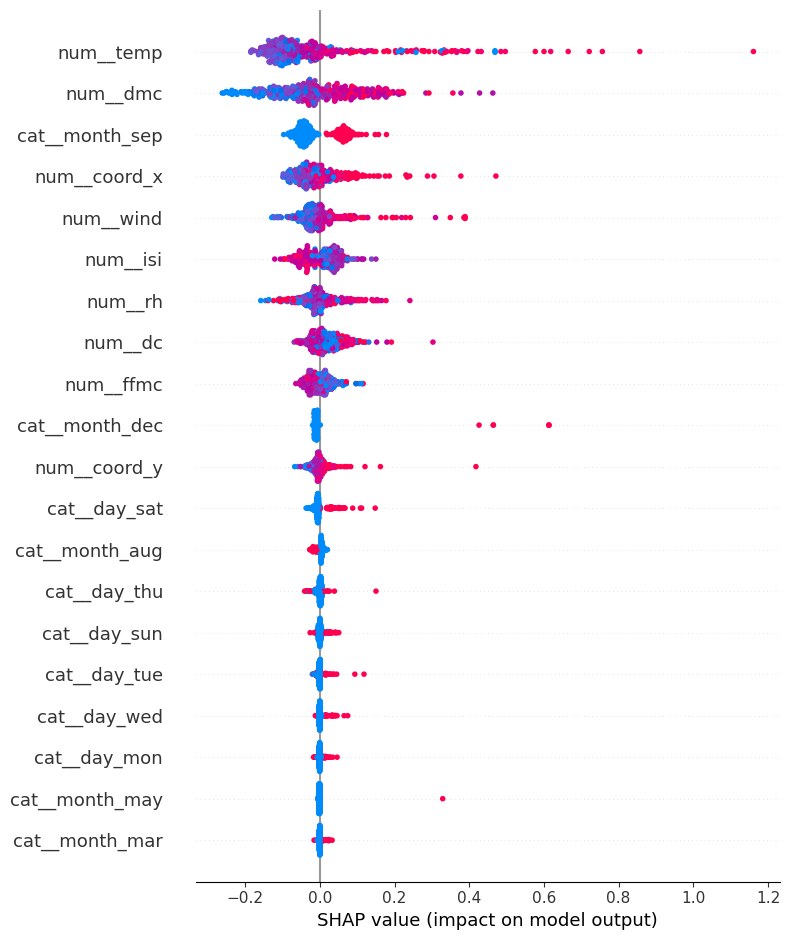

In [146]:
shap.summary_plot(shap_values_train, features=X_train_transformed_df, color_bar=False)


>>> ### Remove features that have very low or negligible SHAP importance across the dataset.
>>> ### Features consistently close to zero contribution can be candidates.

>> ## To test feature impact
>>> ### Perform ablation studies: retrain the model excluding those features.
>>> ### Compare performance metrics (e.g., RMSE) before and after feature removal.
>>> ### If removing features doesn't degrade performance or improves it, those features may be unnecessary.

## Criteria

The [rubric](./assignment_2_rubric_clean.xlsx) contains the criteria for assessment.

## Submission Information

🚨 **Please review our [Assignment Submission Guide](https://github.com/UofT-DSI/onboarding/blob/main/onboarding_documents/submissions.md)** 🚨 for detailed instructions on how to format, branch, and submit your work. Following these guidelines is crucial for your submissions to be evaluated correctly.

### Submission Parameters:
* Submission Due Date: `HH:MM AM/PM - DD/MM/YYYY`
* The branch name for your repo should be: `assignment-2`
* What to submit for this assignment:
    * This Jupyter Notebook (assignment_2.ipynb) should be populated and should be the only change in your pull request.
* What the pull request link should look like for this assignment: `https://github.com/<your_github_username>/production/pull/<pr_id>`
    * Open a private window in your browser. Copy and paste the link to your pull request into the address bar. Make sure you can see your pull request properly. This helps the technical facilitator and learning support staff review your submission easily.

Checklist:
- [ ] Created a branch with the correct naming convention.
- [ ] Ensured that the repository is public.
- [ ] Reviewed the PR description guidelines and adhered to them.
- [ ] Verify that the link is accessible in a private browser window.

If you encounter any difficulties or have questions, please don't hesitate to reach out to our team via our Slack at the `help` channel. Our Technical Facilitators and Learning Support staff are here to help you navigate any challenges.

# Reference

Cortez,Paulo and Morais,Anbal. (2008). Forest Fires. UCI Machine Learning Repository. https://doi.org/10.24432/C5D88D.